### Install Neccessary Libraries

In [2]:
!pip install ir_datasets scikit-learn tqdm

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 13.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.0/135.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.0 MB/s eta 0:00:0000:01
  Created wheel for warc3-wet-clueweb09: filename=warc3_wet_clueweb09-0.2.5-py3-none-any.whl size=18919 sha256=54138edd1a43eecc7f7c9efd93313d0705ae911a25c1b06a0ee278e608542305
  Stored in directory: /root/.cache/pip/wheels/63/f9/dc/2dd16d3330e327236e4d407941975c42d5159d200cdb7922d8
  Created wheel for cbor: filename=cbor-1.0.0-cp311-cp311-linux_x86_64.whl size=53930 sha256=3ac983d3f859885aae2a11ddcb42946180b4bfbd511826f4a8263f453e63bbfc
  Stored in directory: /root/.cache/pip/wheels/21/6b/45/0c34253b1af07d1d9dc524f6d44d74a6b191c43152e6aaf641
Successfully built warc3-wet-clueweb09 c

### Import Necessary Libraries

In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
import joblib
import ir_datasets
import random
import re
from gensim import models
from spacy.lang.en import English
from collections import Counter
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import pickle
from sklearn.metrics import roc_curve, auc, roc_auc_score

### Load Dataset

In [4]:
# Load the SARA dataset
dataset = ir_datasets.load("sara")

# Convert dataset into a DataFrame
df = pd.DataFrame(
    ({"doc_id": doc.doc_id, "text": doc.text, "sensitivity": doc.sensitivity}
     for doc in dataset.docs_iter())
)

# Display label distribution
print("Label counts:\n", df['sensitivity'].value_counts())

[INFO] [starting] building docstore
[INFO] If you have a local copy of https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/f880a35b54bf9fa4d18d1eee8da6f179
[INFO] [starting] https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz
docs_iter:   0%|                                      | 0/1702 [00:00<?, ?doc/s]
https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz: 0.0%| 0.00/4.52M [00:00<?, ?B/s]
https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz: 0.7%| 32.8k/4.52M [00:00<00:18, 245kB/s]
https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz: 3.6%| 164k/4.52M [00:00<00:07, 597kB/s] 
https://bailando.berkeley.edu/enron/enron_with_categories.tar.gz: 15.9%| 721k/4.52M [00:00<00:02, 1.74MB/s]
                                                                                .52M [00:00<00:00, 5.34MB/s]
                                                    

Label counts:
 sensitivity
0    1491
1     211
Name: count, dtype: int64



[INFO] [finished] docs_iter: [00:01] [1702doc] [1245.64doc/s]
[INFO] [finished] building docstore [1.37s]


### Train-Test Split

In [32]:
# Stratified train-test split to preserve class distribution
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['sensitivity']  # ensures balance in sensitivity labels
)

In [33]:
train_df["sensitivity"].value_counts()

sensitivity
0    1192
1     169
Name: count, dtype: int64

In [37]:
test_df["sensitivity"].value_counts()

sensitivity
0    299
1     42
Name: count, dtype: int64

### Classifier Performance Before Data Augmentation

In [8]:
def run_text_classifier_from_files(train_df, test_df, save_model=True):
    
    # Extract features (text) and labels (sensitivity) from training and test sets
    X_train, y_train = train_df['text'], train_df['sensitivity']
    X_test, y_test = test_df['text'], test_df['sensitivity']

    # Define the pipeline with TF-IDF + SVC
    pipeline = make_pipeline(
        TfidfVectorizer(stop_words='english'),
        SVC(random_state=42, class_weight='balanced', probability=True)
    )

    # Define parameter grid for hyperparameter tuning
    param_grid = {
        'svc__C': [0.1, 1, 10],             # regularization strength
        'svc__kernel': ['linear', 'rbf'],   # kernel type
        'svc__gamma': ['scale', 'auto']     # kernel coefficient 
    }

    # Stratified 5-fold cross-validation for tuning
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Grid search with balanced accuracy as scoring metric
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1,         
        verbose=1         
    )

    print("Performing hyperparameter tuning")
    grid_search.fit(X_train, y_train)

    # Best parameters and CV score
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best CV Balanced Accuracy: {grid_search.best_score_:.4f}\n")

    # Train final model with the best parameters on full training data
    best_pipeline = grid_search.best_estimator_
    best_pipeline.fit(X_train, y_train)

    # Predictions on the test set
    predictions = best_pipeline.predict(X_test)
    probabilities = best_pipeline.predict_proba(X_test)

    # Compute evaluation metrics
    bal_acc = balanced_accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro')
    recall = recall_score(y_test, predictions, average='macro')
    cm = confusion_matrix(y_test, predictions)

    # Print evaluation results
    print("Evaluation on Test Set")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Macro F1-Score    : {f1:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}\n")
    print("Confusion Matrix (TN/FP, FN/TP):")
    print(cm)

    # Build results DataFrame with predictions and probabilities
    results_df = pd.DataFrame({
        'doc_id': test_df["doc_id"].reset_index(drop=True),
        'text': X_test.reset_index(drop=True),
        'actual_sensitivity': y_test.reset_index(drop=True),
        'predicted_sensitivity': predictions,
        'probability_0': probabilities[:, 0],
        'probability_1': probabilities[:, 1]
    })
    
    return results_df, best_pipeline

prediction_results, trained_classifier = run_text_classifier_from_files(train_df, test_df)

Performing hyperparameter tuning
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best CV Balanced Accuracy: 0.7230

Evaluation on Test Set
Balanced Accuracy : 0.7151
Macro F1-Score    : 0.6985
Precision         : 0.6856
Recall            : 0.7151

Confusion Matrix (TN/FP, FN/TP):
[[271  28]
 [ 20  22]]


In [15]:
# Separate classes within the training set
train_majority = train_df[train_df['sensitivity'] == 0]
train_minority = train_df[train_df['sensitivity'] == 1]

# train_df.to_csv("sara_train_original.csv", index=False)
test_df.to_csv("test.csv", index=False)

### Word2Vec Implementation for Upsampling the Training Set

In [17]:
# Load pre-trained Word2Vec model (Google News vectors)
word_2_vec = models.KeyedVectors.load_word2vec_format('/kaggle/input/googlenews-vectors-negative300-bin-gz/GoogleNews-vectors-negative300.bin', binary=True)

# Initialize spaCy English tokenizer
nlp = English()

# Get a suitable synonym for a word using Word2Vec
def get_synonyms(word):
    try:
        similar_words = word_2_vec.most_similar(positive=[word], topn=5)
        for new_word, score in similar_words:
            if score > 0.6 and new_word.isalpha() and new_word.lower() != word.lower():
                return new_word
        return word
    except:
        return word

# Remove stopwords, non-alpha tokens, and short words from text
def remove_stopwords(text):
    doc = nlp(text)
    return [token.text for token in doc if not token.is_stop and token.is_alpha and len(token.text) > 2]

# Safely replace a word in a sentence, ignoring case
def safe_word_replace(sentence, old_word, new_word):
    return re.sub(r'\b' + re.escape(old_word) + r'\b', new_word, sentence, flags=re.IGNORECASE)

# Replace up to n words in a sentence with their synonyms
def random_synonym_replace(sentence, n=2):
    words = remove_stopwords(sentence)
    if not words:
        return sentence, []
    words_to_replace = random.sample(words, min(n, len(words)))
    modified = sentence
    replacements = []
    for word in words_to_replace:
        synonym = get_synonyms(word)
        if synonym != word:
            updated = safe_word_replace(modified, word, synonym)
            if updated != modified:
                replacements.append({'original': word, 'synonym': synonym})
                modified = updated
    return modified, replacements

# Generate conservative augmented text variants for a given text
def augment_text_conservative(text, num_variants=1):
    variants = []
    for i in range(num_variants):
        augmented, replacements = random_synonym_replace(text, random.randint(1, 2))
        if replacements and augmented != text:
            variants.append({'text': augmented, 'replacements': replacements, 'variant_id': i + 1})
    return variants

# Upsample minority class using Word2Vec-based synonym augmentation
def word2vec_upsample(train_majority, train_minority):
    target_size = len(train_majority)  # desired size for minority class
    synthetic_needed = target_size - len(train_minority)  # number of synthetic samples required
    synthetic_samples = []
    replacement_stats = []

    # Determine how many variants per minority sample
    per_doc = synthetic_needed // len(train_minority)
    extra = synthetic_needed % len(train_minority)

    # Generate synthetic samples
    for _, row in train_minority.iterrows():
        text = row['text']
        num_variants = per_doc + (1 if extra > 0 else 0)
        if extra > 0:
            extra -= 1
        variants = augment_text_conservative(text, num_variants)
        for variant in variants:
            new_row = row.copy()
            new_row['doc_id'] = f"{row['doc_id']}_syn_{variant['variant_id']}"  # new doc_id for synthetic sample
            new_row['text'] = variant['text']
            synthetic_samples.append(new_row)
            replacement_stats.extend(variant['replacements'])

    # Fill any remaining synthetic samples by copying existing minority samples
    while len(synthetic_samples) < synthetic_needed:
        sample = train_minority.sample(1).iloc[0].copy()
        sample['doc_id'] = f"{sample['doc_id']}_copy_{len(synthetic_samples)}"
        synthetic_samples.append(sample)

    # Combine synthetic samples with original minority class
    synthetic_df = pd.DataFrame(synthetic_samples[:synthetic_needed])
    upsampled_minority = pd.concat([train_minority, synthetic_df], ignore_index=True)
    balanced_train = pd.concat([train_majority, upsampled_minority], ignore_index=True)
    balanced_train = balanced_train.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

    return balanced_train, synthetic_df, replacement_stats

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Perform upsampling
train_balanced, synthetic_dataset, replacement_stats = word2vec_upsample(train_majority, train_minority)

# Save the balanced training set
train_balanced.to_csv("train_balanced.csv", index=False)

# Print completion and class distribution
print("Upsampling complete.")
print("Class distribution in balanced train set:")
print(train_balanced['sensitivity'].value_counts())

Upsampling complete.
Class distribution in balanced train set:
sensitivity
1    1192
0    1192
Name: count, dtype: int64


### Load Balanced Training Dataset

In [21]:
balanced_train_df=pd.read_csv("/kaggle/working/train_balanced.csv")
label_counts = balanced_train_df['sensitivity'].value_counts()

print("Label counts:")
print(label_counts)

Label counts:
sensitivity
1    1192
0    1192
Name: count, dtype: int64


In [36]:
test_df=pd.read_csv("test.csv")
label_counts = test_df['sensitivity'].value_counts()

print("Label counts:")
print(label_counts)

Label counts:
sensitivity
0    299
1     42
Name: count, dtype: int64


### Training SVM Model on Upsampled Data

In [25]:
prediction_results, trained_classifier  = run_text_classifier_from_files(balanced_train_df, test_df)

with open('trained_classifier.pkl', 'wb') as f:
    pickle.dump(trained_classifier, f)

Performing hyperparameter tuning
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV Balanced Accuracy: 0.9815

Evaluation on Test Set
Balanced Accuracy : 0.6245
Macro F1-Score    : 0.6514
Precision         : 0.7137
Recall            : 0.6245

Confusion Matrix (TN/FP, FN/TP):
[[288  11]
 [ 30  12]]


In [26]:
prediction_results.head()

,doc_id,text,actual_sensitivity,predicted_sensitivity,probability_0,probability_1
0,175448,Message-ID: <18686957.1075847598576.JavaMail.e...,0,0,0.999728,0.000272
1,174392,Message-ID: <29549385.1075846176763.JavaMail.e...,0,0,0.998756,0.001244
2,176493,Message-ID: <26049018.1075849864342.JavaMail.e...,0,0,0.998046,0.001954
3,200848,Message-ID: <18958102.1075852079838.JavaMail.e...,0,0,0.999658,0.000342
4,175243,Message-ID: <2591892.1075847582243.JavaMail.ev...,1,0,0.999010,0.000990


### Confusion Matrix

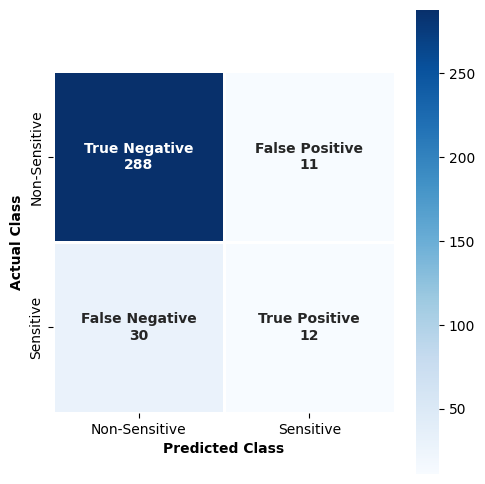

In [27]:
def plot_confusion_matrix(results_df):
    # Extract true labels and predicted labels
    y_true = results_df['actual_sensitivity']
    y_pred = results_df['predicted_sensitivity']
    
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Set up the figure size
    plt.figure(figsize=(5, 5))  # Slightly larger to fit annotations
    
    # Define descriptive labels for each cell
    group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
    group_counts = ['{0:0.0f}'.format(value) for value in cm.flatten()]
    
    # Combine group names and counts for annotation
    labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_names, group_counts)]
    labels = [[labels[0], labels[1]], [labels[2], labels[3]]]  # 2x2 format
    
    # Plot the heatmap using seaborn
    sns.heatmap(
        cm, 
        annot=labels,             # Annotate each cell with name + count
        fmt='',                   # No extra formatting needed
        cmap='Blues',             # Color map
        square=True,              # Keep cells square
        linewidths=1,             # Lines between cells
        xticklabels=['Non-Sensitive', 'Sensitive'],  # X-axis class labels
        yticklabels=['Non-Sensitive', 'Sensitive'],  # Y-axis class labels
        annot_kws={'size': 10, 'weight': 'bold'}    # Annotation text properties
    )
    
    # Axis labels with bold font
    plt.xlabel('Predicted Class', fontsize=10, fontweight='bold')
    plt.ylabel('Actual Class', fontsize=10, fontweight='bold')
    
    # Adjust layout to avoid clipping
    plt.tight_layout()
    
    # Display the plot
    plt.show()


# Call the function to visualize the confusion matrix
plot_confusion_matrix(prediction_results)

### ROC Curve

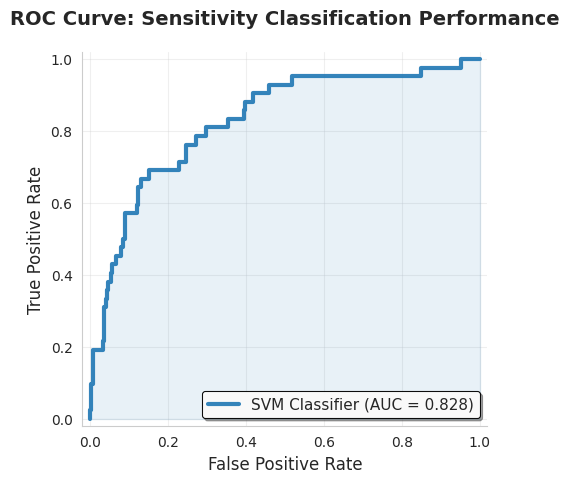

Area Under ROC Curve: 0.8275


In [31]:
def plot_publication_roc_curve(results_df):
    
    # Plot a publication-quality ROC curve for the sensitivity classifier.
    # Returns the computed AUC score

    # Set visual aesthetics
    sns.set_style("whitegrid")  # background grid for readability
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 11,
        'figure.titlesize': 16
    })

    # Compute ROC curve
    y_true = results_df['actual_sensitivity']       # True labels
    y_scores = results_df['probability_1']          # Predicted probabilities for positive class
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)  # False positive rate, True positive rate
    roc_auc = auc(fpr, tpr)                         # Area under the curve

    # Create figure
    fig, ax = plt.subplots(figsize=(5, 5))  # Square figure for better aesthetics

    # Plot ROC curve line
    ax.plot(fpr, tpr, 
            color='#1f77b4', 
            linewidth=3, 
            label=f'SVM Classifier (AUC = {roc_auc:.3f})',
            alpha=0.9)

    # Fill area under the ROC curve lightly
    ax.fill_between(fpr, tpr, color='#1f77b4', alpha=0.1)

    # Customize axes and title
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel('False Positive Rate', fontweight='medium')
    ax.set_ylabel('True Positive Rate', fontweight='medium')
    ax.set_title('ROC Curve: Sensitivity Classification Performance', 
                 fontweight='bold', pad=20)


    # Grid and legend styling
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)  # grid lines below plot elements
    legend = ax.legend(loc='lower right', 
                       frameon=True, 
                       fancybox=True, 
                       shadow=True,
                       framealpha=0.95,
                       edgecolor='black',
                       facecolor='white')
    legend.get_frame().set_linewidth(0.8)

    # Remove top and right spines for cleaner appearance
    sns.despine(ax=ax)

    # Adjust layout
    plt.tight_layout()
    plt.show()

    # Return AUC for reporting
    return roc_auc

# Call the function and print AUC
auc_score = plot_publication_roc_curve(prediction_results)
print(f"Area Under ROC Curve: {auc_score:.4f}")